Random Policy

In [6]:
import gymnasium as gym
import numpy as np
import random
import importlib
import plots
from plots import (
    test_and_compare_hyperparameters,
    compare_algorithms_with_base_params,
    test_convergence_speed,
    print_final_policy,
    base_params, 
    param_variations_td,
    param_variations_mc,
    param_variations_vpi,
)
importlib.reload(plots)

def create_frozenlake_env(size=4, seed=6, is_slippery=True, render_mode=None):
	from gymnasium.envs.toy_text.frozen_lake import generate_random_map
	desc = generate_random_map(size=size, seed=seed)
	env = gym.make('FrozenLake-v1', render_mode=render_mode, desc=desc, is_slippery=is_slippery)
	return env

# Returns a random policy
def random_policy(env, **kwargs):	
	num_states = env.observation_space.n
	num_actions = env.action_space.n
 
	pi = np.random.choice(num_actions, size=num_states)
 
	return pi


# Helper function to view a singular run of the policy
def run_policy(policy, size=4, seed=6):
    preview_env = create_frozenlake_env(size, seed, render_mode='human')
    total_reward = 0
    episode_over = False
        
    obs, _ = preview_env.reset()
    
    while not episode_over:
        preview_env.render()
        action = policy[obs]
        _, reward, terminated, truncated, _ = preview_env.step(action)
        
        total_reward += reward
        episode_over =  terminated or truncated
     
    preview_env.close()    
    return total_reward

# TEST - Shows a single run of the policy
# env = create_frozenlake_env()
# pi_random = random_policy(env)
# print(pi_random)
# print(f'Total reward: {run_policy(pi_random)}')
# env.close()

Policy Iteration and Value Iteration

In [7]:
import gymnasium as gym
from gymnasium import envs
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
import numpy as np
import random

# POLICY ITERATION
def policy_eval(env, pi, v, gamma, theta,**kwargs):
	delta = float('inf')
	num_states = env.observation_space.n

	while delta > theta:
		old_v = np.copy(v)    
		delta = 0
		
		for s in range(num_states):
			a = pi[s]
			v_s = 0.0
			
			for (trans_p, next_state, reward, _) in env.unwrapped.P[s][a]:
				v_s += trans_p * (reward + gamma * old_v[next_state])
				
			v[s] = v_s
			delta = max(delta, abs(v[s] - old_v[s]))
	

def policy_improvement(env, pi, v, gamma, **kwargs):
	num_states = env.observation_space.n
	num_actions = env.action_space.n
	policy_stable = True
	
	for s in range(num_states):
		old_action = pi[s]
		best_a = None
		max_action_val = float('-inf')
		
		for a in range(num_actions):
			a_val = 0.0
			
			for (trans_p, next_state, reward, _) in env.unwrapped.P[s][a]:
				a_val += trans_p * (reward + gamma * v[next_state])
				
			if a_val > max_action_val:
				max_action_val = a_val
				best_a = a
			
		pi[s] = best_a
		
		if old_action != pi[s]:
			policy_stable = False
   	
	return policy_stable
	
		
def policy_iteration(env, gamma=0.5, theta=1e-4, max_iter=1000, **kwargs):
	num_states = env.observation_space.n
	
	# Initializing v and pi arbitrarily
	v = np.zeros(num_states)
	pi = {s: env.action_space.sample() for s in range(num_states)}
	
	for i in range(max_iter):
		policy_eval(env, pi, v, gamma, theta)
		stable = policy_improvement(env, pi, v, gamma)
		if stable:
			return v, pi, i+1
	return v, pi, max_iter

# VALUE ITERATION
def value_iteration(env, gamma=0.5, theta=1e-4):
	num_states = env.observation_space.n
	num_actions = env.action_space.n
 
 	# Initializing v and pi arbitrarily
	v = np.zeros(num_states)
	pi = {s: env.action_space.sample() for s in range(num_states)}
  
	delta=float('inf')
	iterations = 0
	while delta>theta:
		iterations += 1
		delta=0
		old_v=v.copy()
		
		#Loop for each state s
		for s in range(num_states):
			action_values = []
   
			for a in range(num_actions):
				v_s = sum(trans_p * (reward + gamma * old_v[next_state]) for trans_p, next_state, reward, _ in env.unwrapped.P[s][a])
				action_values.append(v_s)
    
					
			v[s] = np.max(action_values)
			best_a = np.argmax(action_values)			
			pi[s] = best_a #assign optimal policy
   
			delta = max (delta,abs(old_v[s]-v[s]))
			
	return v, pi, iterations


# TEST Policy Iteration - Shows a single run of the policy
# env = create_frozenlake_env(size=12, seed=4)
# v, pi_pi, iters = policy_iteration(env)
# print(v)
# print(iters)
# print(f'Total reward: {run_policy(pi_pi, size=12, seed=4)}, Iterations till convergence: {iters}')
# env.close()

# TEST Value Iteration - Shows a single run of the policy
# env = create_frozenlake_env(size=12, seed=4)
# v, pi_vi, iters = policy_iteration(env)
# print(v)
# print(iters)
# print(f'Total reward: {run_policy(pi_vi, size=12, seed=4)}, Iterations till convergence: {iters}')
# env.close()

Monte Carlo - Prediction and Control with ES

In [8]:

def mc_prediction(env, pi, max_episodes=10000, gamma=0.9):
	#Initialization
	num_states = env.observation_space.n
	v = np.zeros(num_states)
	returns = {s: [] for s in range(num_states)}
	
	# Main Loop
	for _ in range(max_episodes):  
		obs, _ = env.reset()
		episode = []
		episode_over = False
		
		# Generating an episode
		while not episode_over:
			action = pi[obs]
			next_state, reward, terminated, truncated, _ = env.step(action)
			
			episode.append((obs, action, reward))
			obs = next_state
			episode_over =  terminated or truncated
		
		G = 0.0
		for t in reversed(range(len(episode))):
			state, action, reward = episode[t]
			G = gamma*G + reward
   
			# Forward loop until t-1 to check if 'state' appears before in the episode sequence
			if not any(episode[i][0] == state for i in range(t)):
				returns[state].append(G)
	
	# The mean average of G for each state
	for s in range(num_states):
		if len(returns[s]) > 0.0:
			v[s] = np.mean(returns[s])
  
	return v


def mc_control_es(env, max_episodes=10000, gamma=0.9, **kwargs):
	#Initialization
	num_states = env.observation_space.n
	num_actions = env.action_space.n

	Q = np.zeros((num_states, num_actions))
	pi = {s: 0 for s in range(num_states)}
 
	returns = {(s,a): [] for s in range(num_states) for a in range (num_actions)}
	episode_rewards = []
	
	# Main Loop
	for _ in range(max_episodes):  
		# Exploring starts - picking a random starting state and action
		s0 = np.random.choice(num_states)
		a0 = np.random.choice(num_actions)
  
		# Generating an episode
		env.reset()
		env.unwrapped.s = s0
	
		episode = []
		episode_over = False
		total_reward = 0

  
		# First (Random) step
		next_state, reward, terminated, truncated, _ = env.step(a0)
		episode.append((s0, a0, reward))
		s = next_state
		
		while not episode_over:
			action = pi[s]
			next_state, reward, terminated, truncated, _ = env.step(action)
			
			episode.append((s, action, reward))
			s = next_state
   
			total_reward += reward
			episode_over =  terminated or truncated
   
		episode_rewards.append(total_reward)
		
		G = 0.0
		# Loop backwards through the episode - Make use of the recursive property of G
		for t in reversed(range(len(episode))):
			state, action, reward = episode[t]
			G = gamma*G + reward
   
			# Forward loop until t-1 to check if 'state-action' appears before in the episode sequence (first-vist)
			if not any((episode[i][0] == state and episode[i][1] == action) for i in range(t)):
				returns[(state, action)].append(G)
				Q[state, action] = np.mean(returns[(state, action)])
				pi[state] = np.argmax(Q[state, :])

	return Q, pi, episode_rewards

# TEST - MC Control - Shows a single run of the policy
# env = create_frozenlake_env(size=4, seed=6, is_slippery=True)
# Q_mc, pi_mc, _ = mc_control_es(env, num_episodes=1000, gamma=0.9)
# print("MC Control Policy:")
# print(pi_mc)
# print(f'Total reward: {run_policy(pi_mc)}')
# env.close()

TD(0), SARSA and, QLearning

In [9]:
def epsilon_greedy(Q, state, epsilon, num_actions):
    # Exploration
    if random.random() < epsilon:
        return np.random.choice(num_actions)
    # Exploitation
    else:
        return np.argmax(Q[state])       

# TD Prediction: TD(0) for state-value
def TD_zero(env, pi, alpha, max_episodes=10000, gamma=0.9):
    num_states = env.observation_space.n
    v = np.zeros(num_states)
            
    for _ in range(max_episodes):
        s, _ = env.reset()
        episode_over = False
        
        while not episode_over:
            action = pi[s]
            next_state, reward, terminated, truncated, _ = env.step(action)
            
            v[s] = v[s] + alpha * (reward + gamma*v[next_state] - v[s])
            
            s = next_state
            episode_over =  terminated or truncated       
        
    return v

# On-policy TD Control algorithm: Sarsa
def sarsa(env, max_episodes=10000, alpha=0.1, gamma=0.9, initial_epsilon=0.1, min_epsilon=0.01, **kwargs):
    num_states = env.observation_space.n
    num_actions = env.action_space.n
    Q = np.zeros((num_states, num_actions))
    epsilon = initial_epsilon
    episode_rewards = []

    for episode in range(max_episodes):
        # decreasing epsilon 
        epsilon = max(min_epsilon, initial_epsilon * (1 - episode/max_episodes))
        
        s, _ = env.reset()
        action = epsilon_greedy(Q, s, epsilon, num_actions)
        total_reward = 0
        episode_over = False
        
        while not episode_over:
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon, num_actions)
            
            Q[s][action] = Q[s][action] + alpha*(reward + gamma*Q[next_state][next_action] - Q[s][action])
            
            s = next_state
            action = next_action
            
            total_reward += reward
            episode_over =  terminated or truncated 
        
        episode_rewards.append(total_reward) 

    return Q, episode_rewards

# Off-policy TD Control algorithm: Q-learning 
def Q_learning(env, max_episodes=10000, alpha=0.1, gamma=0.9, initial_epsilon=0.1, min_epsilon=0.01, **kwargs):
    num_states = env.observation_space.n
    num_actions = env.action_space.n
    Q = np.zeros((num_states, num_actions))  
    epsilon = initial_epsilon
    episode_rewards = []
    
    for episode  in range(max_episodes):
        # decreasing epsilon
        epsilon = max(min_epsilon, initial_epsilon * (1 - episode/max_episodes)) 
        
        s, _ = env.reset()
        total_reward = 0
        episode_over = False

        while not episode_over:
            action = epsilon_greedy(Q, s, epsilon, num_actions)
            next_state, reward, terminated, truncated, _ = env.step(action)
            
            # Q-learning update            
            Q[s][action] = Q[s][action] + alpha * (reward + gamma * np.max(Q[next_state]) - Q[s][action])
            
            s = next_state
            
            total_reward += reward
            episode_over = terminated or truncated
            
        episode_rewards.append(total_reward)  
            
    return Q, episode_rewards

# TEST - SARSA - Shows a single run of the policy
# env = create_frozenlake_env(size=4, seed=6, is_slippery=True)
# sarsa_results, episode_rewards = sarsa(env)
# print("SARSA final Q-values:")
# print(sarsa_results)
# final_policy_sarsa = np.argmax(sarsa_results, axis=1) #final policy (greedy based on Q-values)
# print("Final Policy:")
# print(final_policy_sarsa)
# print(sum(episode_rewards))
# print(f'Total reward: {run_policy(final_policy_sarsa)}')
# env.close()
    
# TEST - QLEARNING - Shows a single run of the policy
# env = create_frozenlake_env(size=4, seed=6, is_slippery=True)
# qlearn, episode_rewards = Q_learning(env)
# print("Q-learning final Q-values:")
# print(qlearn)
# final_policy_qlearn = np.argmax(qlearn, axis=1) #final policy (greedy based on Q-values)
# print("Final Policy:")
# print(final_policy_qlearn)
# print(sum(episode_rewards))
# print(f'Total reward: {run_policy(final_policy_qlearn)}')
# env.close()

Evaluating the algorithms

EVALUATING POLICY ITERATION:


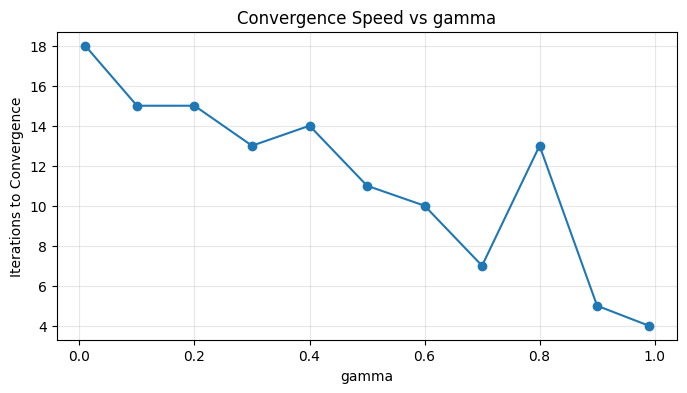

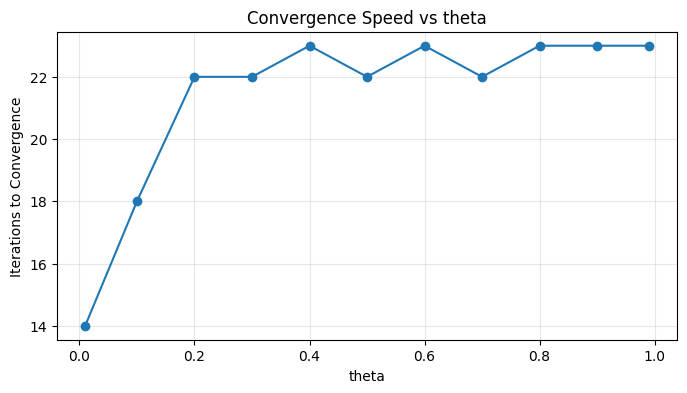

EVALUATING VALUE ITERATION:


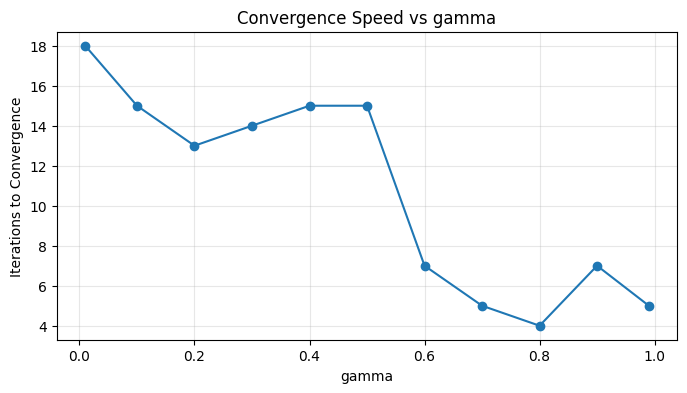

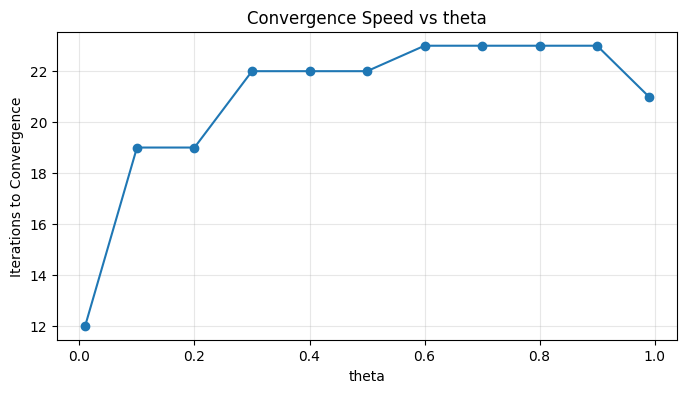

Final Policy: Policy and Value Iteration


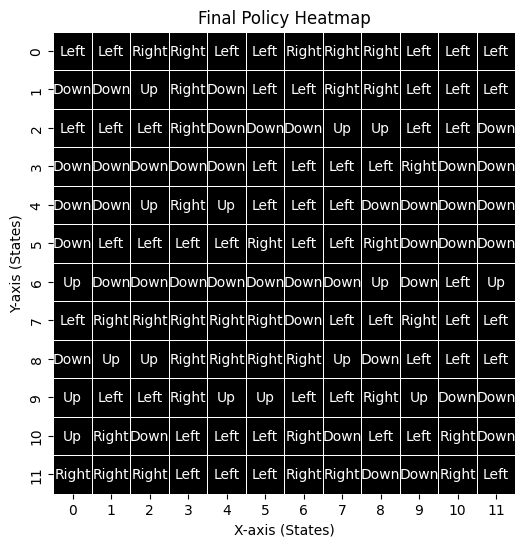

EVALUATING MC CONTROL:
Testing: gamma=0.01
Testing: gamma=0.1
Testing: gamma=0.2
Testing: gamma=0.3
Testing: gamma=0.4
Testing: gamma=0.5
Testing: gamma=0.6
Testing: gamma=0.7
Testing: gamma=0.8
Testing: gamma=0.9
Testing: gamma=0.99

Best hyperparameters:
Gamma: gamma=0.9 (42.00%)


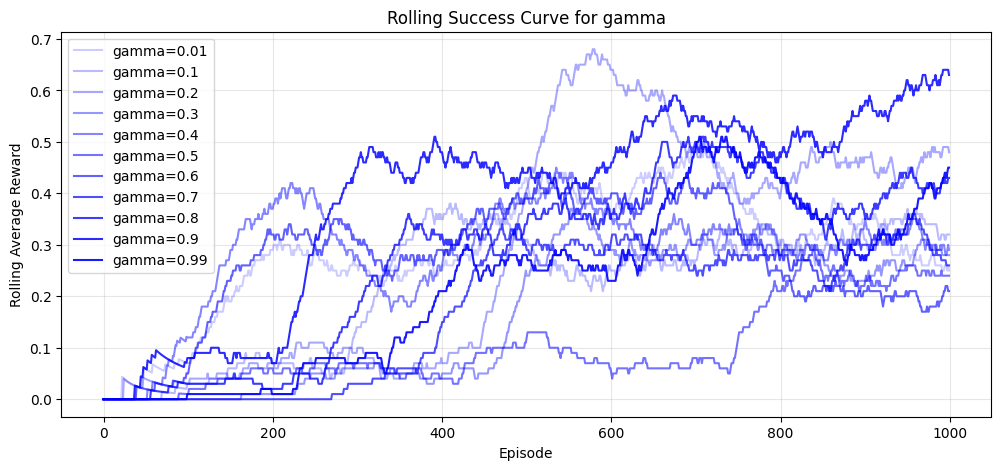

EVALUATING SARSA:
Testing: alpha=0.01
Testing: alpha=0.1
Testing: alpha=0.2
Testing: alpha=0.3
Testing: alpha=0.4
Testing: alpha=0.5
Testing: alpha=0.6
Testing: alpha=0.7
Testing: alpha=0.8
Testing: alpha=0.9
Testing: alpha=0.99
Testing: gamma=0.01
Testing: gamma=0.1
Testing: gamma=0.2
Testing: gamma=0.3
Testing: gamma=0.4
Testing: gamma=0.5
Testing: gamma=0.6
Testing: gamma=0.7
Testing: gamma=0.8
Testing: gamma=0.9
Testing: gamma=0.99
Testing: initial_epsilon=0.01
Testing: initial_epsilon=0.1
Testing: initial_epsilon=0.2
Testing: initial_epsilon=0.3
Testing: initial_epsilon=0.4
Testing: initial_epsilon=0.5
Testing: initial_epsilon=0.6
Testing: initial_epsilon=0.7
Testing: initial_epsilon=0.8
Testing: initial_epsilon=0.9
Testing: initial_epsilon=0.99

Best hyperparameters:
Alpha: alpha=0.01 (64.50%)
Gamma: gamma=0.99 (69.10%)
Initial Epsilon: initial_epsilon=0.3 (69.70%)


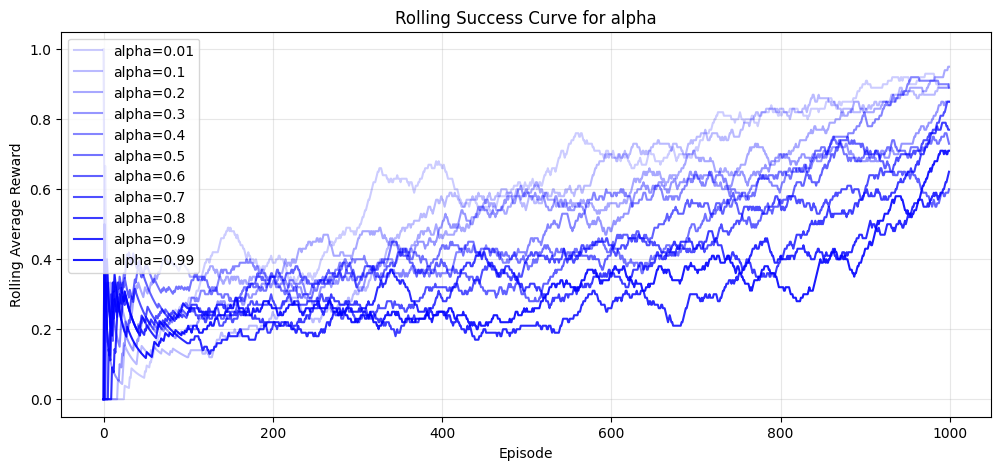

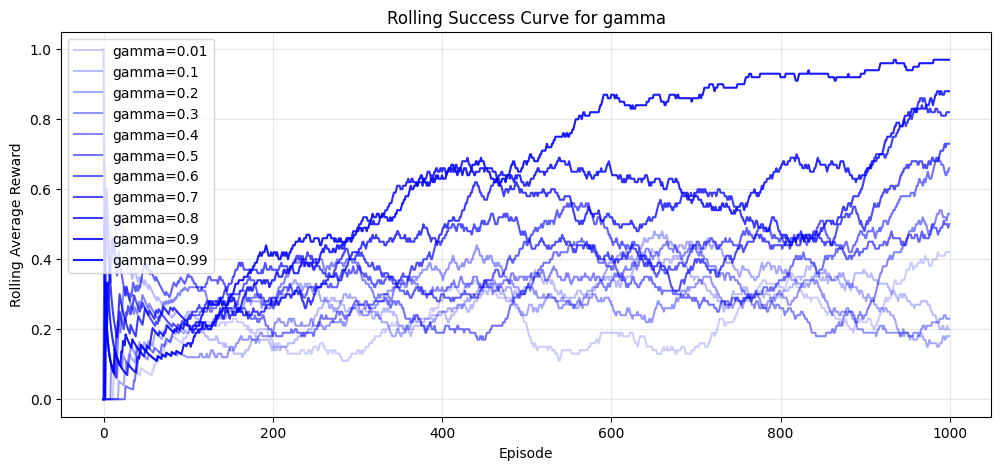

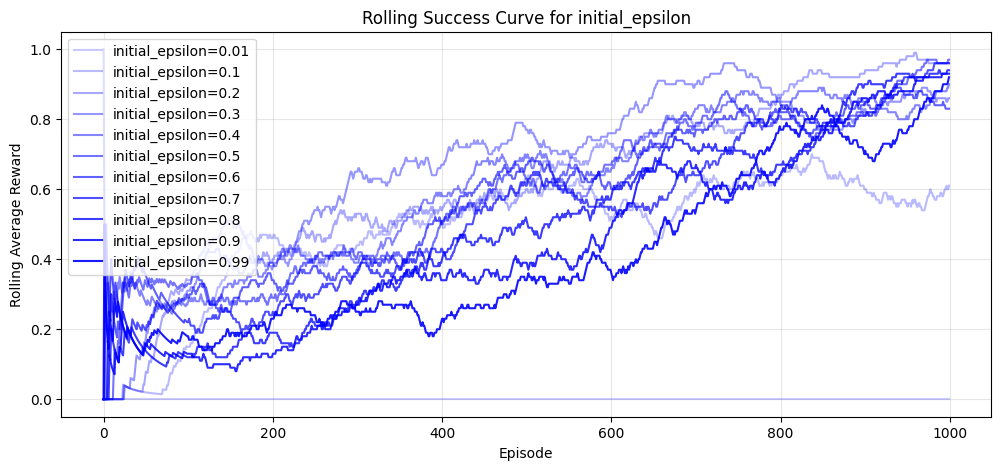

EVALUATING QLEARNING:
Testing: alpha=0.01
Testing: alpha=0.1
Testing: alpha=0.2
Testing: alpha=0.3
Testing: alpha=0.4
Testing: alpha=0.5
Testing: alpha=0.6
Testing: alpha=0.7
Testing: alpha=0.8
Testing: alpha=0.9
Testing: alpha=0.99
Testing: gamma=0.01
Testing: gamma=0.1
Testing: gamma=0.2
Testing: gamma=0.3
Testing: gamma=0.4
Testing: gamma=0.5
Testing: gamma=0.6
Testing: gamma=0.7
Testing: gamma=0.8
Testing: gamma=0.9
Testing: gamma=0.99
Testing: initial_epsilon=0.01
Testing: initial_epsilon=0.1
Testing: initial_epsilon=0.2
Testing: initial_epsilon=0.3
Testing: initial_epsilon=0.4
Testing: initial_epsilon=0.5
Testing: initial_epsilon=0.6
Testing: initial_epsilon=0.7
Testing: initial_epsilon=0.8
Testing: initial_epsilon=0.9
Testing: initial_epsilon=0.99

Best hyperparameters:
Alpha: alpha=0.2 (62.90%)
Gamma: gamma=0.99 (68.60%)
Initial Epsilon: initial_epsilon=0.3 (62.40%)


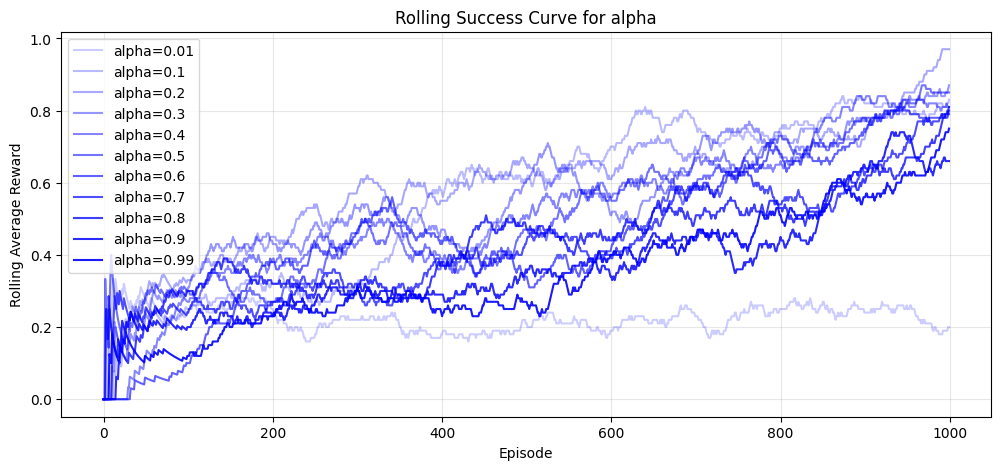

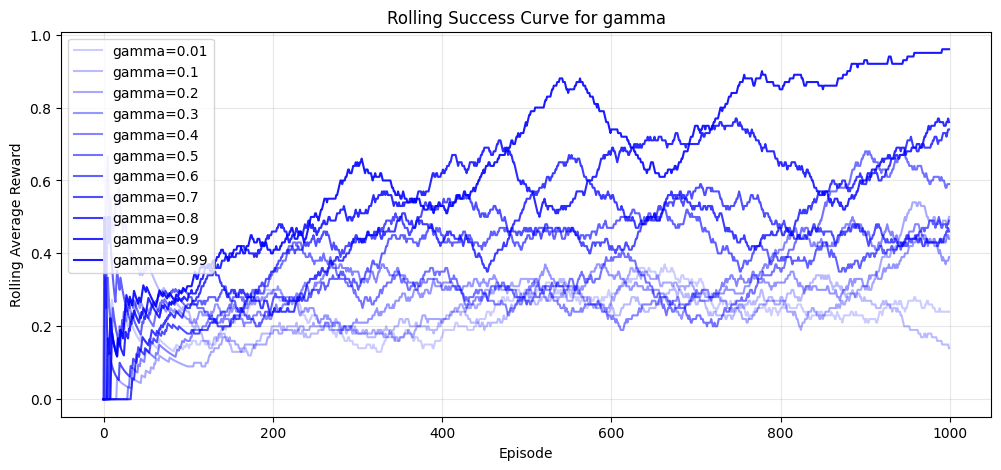

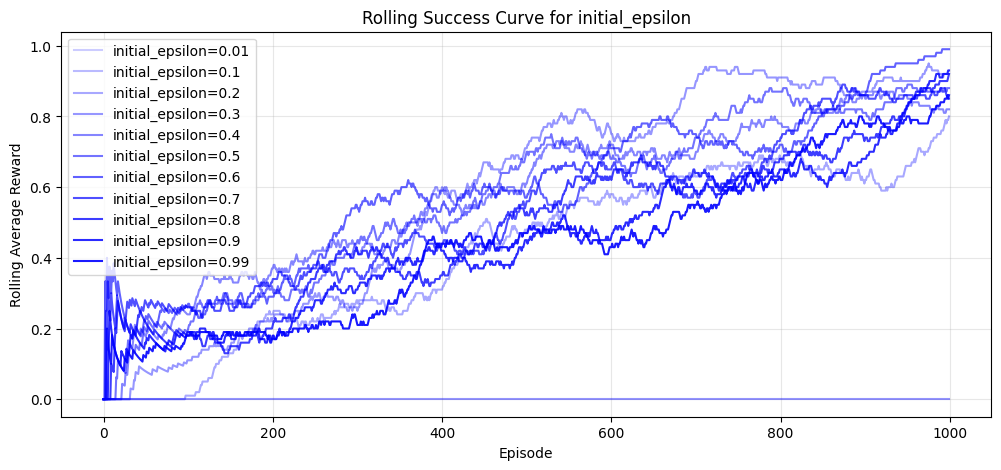

Final Policy for random_policy:


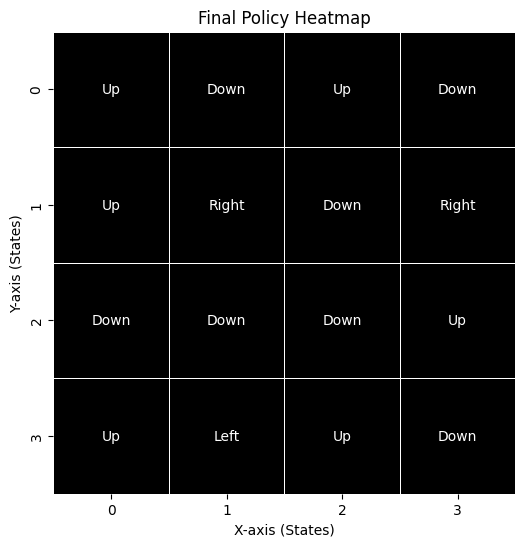

----------------------------------------
Final Policy for mc_control_es:


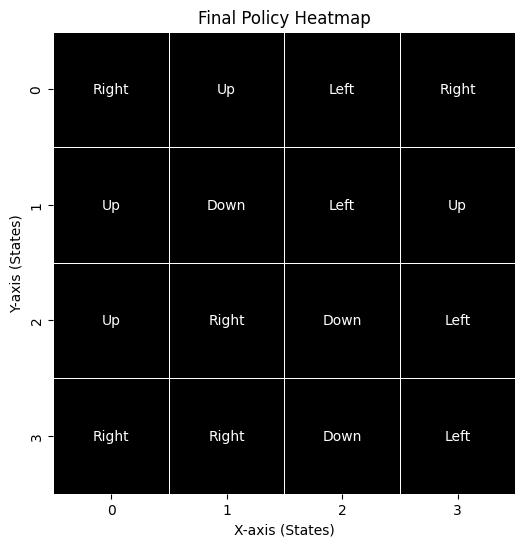

----------------------------------------
Final Policy for sarsa:


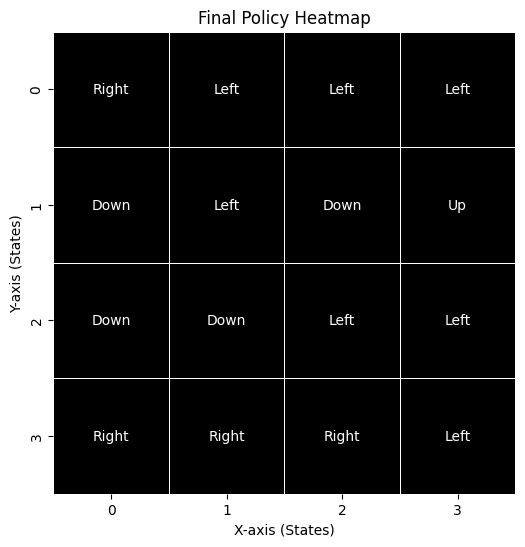

----------------------------------------
Final Policy for Q_learning:


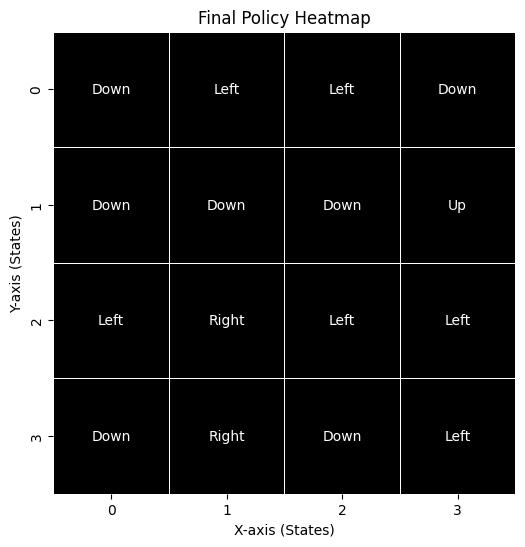

----------------------------------------


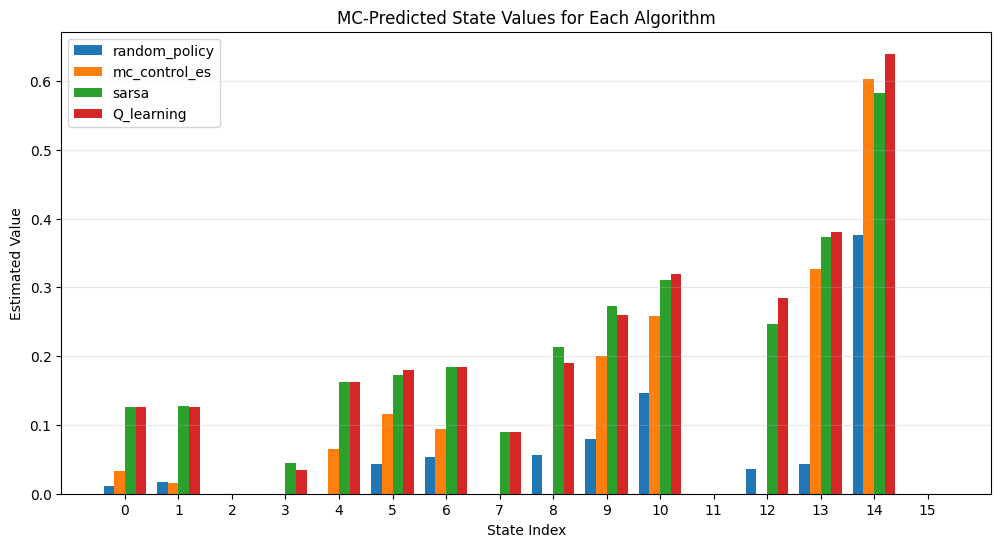

In [10]:
# Plotting the results of all experiments


# Policy Iteration
print("EVALUATING POLICY ITERATION:")
pi_PI = test_convergence_speed(policy_iteration, base_params, param_variations_vpi, env_params={'size': 12, 'seed': 4, 'is_slippery': True})

# Value Iteration
print("EVALUATING VALUE ITERATION:")
pi_VI = test_convergence_speed(policy_iteration, base_params, param_variations_vpi, env_params={'size': 12, 'seed': 4, 'is_slippery': True})
 
# Print policies of Policy Iteration and Value Iteration
env_PIVI = create_frozenlake_env(12, 4)
print("Final Policy: Policy and Value Iteration")
print_final_policy(env_PIVI, pi_PI)
 

# Monte Carlo Control - with Exploring Starts
print("EVALUATING MC CONTROL:")
results_mc_es = test_and_compare_hyperparameters(mc_control_es, base_params, param_variations_mc, env_params={'size': 4, 'seed': 6, 'is_slippery': True}, eval_episodes=1000)

# ON-Policy TD Control - SARSA
print("EVALUATING SARSA:")
results_sarsa = test_and_compare_hyperparameters(sarsa, base_params, param_variations_td, env_params={'size': 4, 'seed': 6, 'is_slippery': True}, eval_episodes=1000)

# OFF-Policy TD Control - QLearning
print("EVALUATING QLEARNING:")
results_qlearning = test_and_compare_hyperparameters(Q_learning, base_params, param_variations_td, env_params={'size': 4, 'seed': 6, 'is_slippery': True}, eval_episodes=1000)


# Plots the state values (using MC prediction) for each state, for each algorithm and their respective policies.
algorithms_to_compare = [random_policy, mc_control_es, sarsa, Q_learning]
compare_algorithms_with_base_params(algorithms_to_compare, base_params, env_params={'size': 4, 'seed': 6, 'is_slippery': True}, eval_episodes=1000)